In [1]:
import sys
sys.path.append('.')

import anndata
import time, os, sys
from datetime import datetime

import pandas as pd
import glob
pd.set_option('display.float_format', lambda x: '%.2f' % x)
import numpy as np

#import skimage.io as io
import scimap as sm
import scanpy as sc

# libraries for patch function
# Import library
import pandas as pd#
from sklearn.neighbors import BallTree
import numpy as np
from joblib import Parallel, delayed
import scipy
from functools import reduce

import matplotlib.pyplot as plt
import seaborn as sns

Running SCIMAP  2.1.3


/Users/chiaraschiller/miniconda3/envs/scimap_local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



This script runs COZI on simulated data using the scimap fork github.com/SchapiroLabor/scimap_COZI

In [5]:
# Load in dataset. This is a .csv file with all samples concatenated together, either for symmetric or asymmetric data
path_to_csv = './../../../../SPIAT/SPIAT/data/spasim_data/'

In [6]:

# read in all csv files (they all have ct, x and y coordinates) give them a new sample id column of their file names and row bind them all to one big dataframe
# Use glob to get all the CSV files in the folder
csv_files = glob.glob(os.path.join(path_to_csv, '*.csv'))

# Initialize an empty list to store individual DataFrames
data_frames = []

# Loop through the CSV files and process each one
for file in csv_files:
    # Read the CSV file into a DataFrame
    df = pd.read_csv(file)
    sample_id = os.path.splitext(os.path.basename(file))[0]
    df['sample_id'] = sample_id
    data_frames.append(df)
    
# Concatenate all DataFrames into one big DataFrame
obs = pd.concat(data_frames, ignore_index=True)


In [15]:
obs

,Unnamed: 0,Cell.X.Position,Cell.Y.Position,Cell.Type,sample_id
0,Cell_55,156.40,349.08,Others,two_cluster_g2p_5
1,Cell_2226,878.68,633.47,Purple,two_cluster_g2p_5
2,Cell_1113,569.03,489.37,Purple,two_cluster_g2p_5
3,Cell_4788,1996.04,292.19,Others,two_cluster_g2p_5
4,Cell_4600,1756.87,1608.02,Others,two_cluster_g2p_5
...,...,...,...,...,...
114995,Cell_1136,425.06,389.68,Purple,two_cluster_g2p_8
114996,Cell_1438,476.53,1612.20,Others,two_cluster_g2p_8
114997,Cell_2213,935.88,665.85,Purple,two_cluster_g2p_8
114998,Cell_1969,687.94,1702.76,Others,two_cluster_g2p_8


In [24]:
# save obs as csv file that I can open it in german excel, currently I see commas and not semicolons as separator
obs['Cell.X.Position'] = obs['Cell.X.Position'].round(2)
obs['Cell.Y.Position'] = obs['Cell.Y.Position'].round(2)
obs.to_excel("./../../../../../data/Source_data/Source_4a.xlsx")

In [6]:
# for image, show the counts of unique ct
print(obs['Cell.Type'].value_counts())

Cell.Type
Others    72613
Purple    21803
Green     20584
Name: count, dtype: int64


In [26]:
# add marker files to it
obs['D'] = np.random.randint(1, 101, size=len(obs))
obs['E'] = np.random.randint(1, 101, size=len(obs))

# Load dataframe into anndata object
# dataframe for annotating the observations
obs = obs.astype({'Cell.Type':'string'})

# the data matrix 
X = obs[['D', 'E']]
X = X.values
adata = anndata.AnnData(X)
adata.obs = obs

adata.obs

,Unnamed: 0,Cell.X.Position,Cell.Y.Position,Cell.Type,sample_id,D,E
0,Cell_55,156.40,349.08,Others,two_cluster_g2p_5,71,2
1,Cell_2226,878.68,633.47,Purple,two_cluster_g2p_5,33,71
2,Cell_1113,569.03,489.37,Purple,two_cluster_g2p_5,42,9
3,Cell_4788,1996.04,292.19,Others,two_cluster_g2p_5,99,79
4,Cell_4600,1756.87,1608.02,Others,two_cluster_g2p_5,52,83
...,...,...,...,...,...,...,...
114995,Cell_1136,425.06,389.68,Purple,two_cluster_g2p_8,44,10
114996,Cell_1438,476.53,1612.20,Others,two_cluster_g2p_8,51,68
114997,Cell_2213,935.88,665.85,Purple,two_cluster_g2p_8,78,67
114998,Cell_1969,687.94,1702.76,Others,two_cluster_g2p_8,18,44


In [27]:
# run spatial interaction to look at interaction of phenotypes without motifs
sm.tl.spatial_interaction(adata, 
                          phenotype='Cell.Type', 
                          x_coordinate='Cell.X.Position', y_coordinate='Cell.Y.Position', 
                          imageid='sample_id', 
                          permutation = 300,
                          method='delaunay',
                          verbose=True,
                          normalization = 'conditional',
                          pval_method = 'zscore',
                          label='cozi_scimap')

Processing Image: ['two_cluster_g2p_5']
Retaining 3 phenotypes with ≥ 10 cells
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['two_cluster_g2p_4']
Retaining 3 phenotypes with ≥ 10 cells
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['two_cluster_g2p_6']
Retaining 3 phenotypes with ≥ 10 cells
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['two_cluster_g2p_7']
Retaining 3 phenotypes with ≥ 10 cells
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processi

AnnData object with n_obs × n_vars = 115000 × 2
    obs: 'Unnamed: 0', 'Cell.X.Position', 'Cell.Y.Position', 'Cell.Type', 'sample_id', 'D', 'E'
    uns: 'cozi_scimap'

In [43]:
# run spatial interaction to look at interaction of phenotypes without motifs
sm.tl.spatial_interaction(adata, 
                          phenotype='Cell.Type', 
                          x_coordinate='Cell.X.Position', y_coordinate='Cell.Y.Position', 
                          imageid='sample_id', 
                          permutation = 300,
                          method='delaunay',
                          verbose=True,
                          normalization = 'total',
                          pval_method = 'zscore',
                          label='sea_scimap')

Processing Image: ['two_cluster_g2p_5']
Retaining 3 phenotypes with ≥ 10 cells
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['two_cluster_g2p_4']
Retaining 3 phenotypes with ≥ 10 cells
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['two_cluster_g2p_6']
Retaining 3 phenotypes with ≥ 10 cells
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['two_cluster_g2p_7']
Retaining 3 phenotypes with ≥ 10 cells
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processi

AnnData object with n_obs × n_vars = 115000 × 2
    obs: 'Unnamed: 0', 'Cell.X.Position', 'Cell.Y.Position', 'Cell.Type', 'sample_id', 'D', 'E'
    uns: 'cozi_scimap', 'sea_scimap'

In [30]:
adata.uns['cozi_scimap']

,phenotype,neighbour_phenotype,zscore_two_cluster_g2p_5,pvalue_two_cluster_g2p_5,cond_cell_ratio_two_cluster_g2p_5,cond_cell_count_two_cluster_g2p_5,zscore_two_cluster_g2p_4,pvalue_two_cluster_g2p_4,cond_cell_ratio_two_cluster_g2p_4,cond_cell_count_two_cluster_g2p_4,...,cond_cell_ratio_two_cluster_p2g_2,cond_cell_count_two_cluster_p2g_2,zscore_two_cluster_p2g_3,pvalue_two_cluster_p2g_3,cond_cell_ratio_two_cluster_p2g_3,cond_cell_count_two_cluster_p2g_3,zscore_two_cluster_g2p_8,pvalue_two_cluster_g2p_8,cond_cell_ratio_two_cluster_g2p_8,cond_cell_count_two_cluster_g2p_8
0,Green,Green,116.65,0.00,0.98,1435,121.70,0.00,0.97,1347,...,1.00,1039,105.59,0.00,1.00,945,116.75,0.00,1.00,1677
1,Green,Others,-54.29,0.00,0.12,180,-50.24,0.00,0.12,171,...,0.12,122,-33.78,0.00,0.11,105,-64.22,0.00,0.12,210
2,Green,Purple,100.23,0.00,0.30,441,106.81,0.00,0.24,333,...,0.48,500,-9.53,0.00,0.66,629,48.89,0.00,0.39,656
3,Others,Green,-18.03,0.00,0.07,209,-14.66,0.00,0.07,200,...,0.05,147,3.98,0.00,0.05,139,-30.91,0.00,0.08,245
4,Others,Others,161.09,0.00,1.00,2879,158.31,0.00,1.00,2835,...,1.00,2733,154.76,0.00,1.00,2775,166.47,0.00,1.00,2996
5,Others,Purple,3.97,0.00,0.04,106,6.37,0.00,0.04,116,...,0.05,150,-6.55,0.00,0.06,180,9.20,0.00,0.02,48
6,Purple,Green,10.95,0.00,0.92,612,2.17,0.03,0.82,633,...,0.10,121,124.10,0.00,0.17,214,32.89,0.00,1.00,323
7,Purple,Others,-29.03,0.00,0.11,72,-33.27,0.00,0.11,88,...,0.11,135,-42.85,0.00,0.12,153,-28.01,0.00,0.10,34
8,Purple,Purple,67.05,0.00,1.00,660,88.59,0.00,1.00,773,...,0.95,1167,135.38,0.00,0.95,1215,19.25,0.00,0.86,278


In [31]:
save_df = adata.uns['cozi_scimap']
# Convert 'phenotype' and 'neighbour_phenotype' columns to string types
save_df['phenotype'] = save_df['phenotype'].astype(str)
save_df['neighbour_phenotype'] = save_df['neighbour_phenotype'].astype(str)

# Combine 'phenotype' and 'neighbour_phenotype' into 'new_column'
save_df['new_column'] = save_df['phenotype'] + "_" + save_df['neighbour_phenotype']
save_df = save_df.drop(columns=['phenotype', 'neighbour_phenotype'])
save_df = save_df.set_index('new_column')

# Transpose the dataframe
save_df_transposed = save_df.transpose()
save_df_transposed.columns = save_df_transposed.columns.str.replace(r"\.0",
                                                                    "",
                                                                    regex=True)
save_df_transposed = save_df_transposed[~save_df_transposed.index.str.contains('pvalue')]
save_df_transposed = save_df_transposed[~save_df_transposed.index.str.contains('count')]
save_df_transposed = save_df_transposed[~save_df_transposed.index.str.contains('cond_cell')]
save_df_transposed.index = save_df_transposed.index.str.replace(r"zscore_", "", regex=True)

# View the transposed dataframe (optional)
save_df_transposed = save_df_transposed.sort_index().transpose()


In [32]:
interactions_to_keep = ['Green_Green', 'Green_Purple', 'Purple_Green', 'Purple_Purple']

# Since you set 'new_column' as index, you can filter like this:
save_df_filtered = save_df_transposed.loc[save_df.index.isin(interactions_to_keep)]
save_df_filtered

,one_cluster_purple_1,one_cluster_purple_2,one_cluster_purple_3,one_cluster_purple_4,one_cluster_purple_5,one_cluster_purple_6,one_cluster_purple_7,two_cluster_g2p_1,two_cluster_g2p_2,two_cluster_g2p_3,...,two_cluster_g2p_7,two_cluster_g2p_8,two_cluster_p2g_1,two_cluster_p2g_2,two_cluster_p2g_3,two_cluster_p2g_4,two_cluster_p2g_5,two_cluster_p2g_6,two_cluster_p2g_7,two_cluster_p2g_8
new_column,,,,,,,,,,,,,,,,,,,,,
Green_Green,5.48,10.84,23.45,34.19,44.66,69.98,77.11,148.15,135.31,126.08,...,120.85,116.75,147.06,123.54,105.59,76.85,67.50,50.94,33.64,18.69
Green_Purple,35.47,44.08,55.25,49.59,54.08,38.28,33.93,-66.75,136.35,133.08,...,68.44,48.89,-67.39,-18.56,-9.53,4.57,11.60,19.54,26.59,32.61
Purple_Green,10.91,17.24,31.57,42.05,49.06,53.01,53.58,-66.75,-22.15,-6.72,...,29.32,32.89,-65.52,141.84,124.10,108.03,86.10,83.08,56.99,43.65
Purple_Purple,124.57,106.10,90.32,67.42,52.00,33.59,24.09,152.78,132.09,97.67,...,35.42,19.25,147.82,157.11,135.38,113.78,114.41,114.34,113.23,122.12


In [37]:
# save save_df_filtered as xlxs
save_df_filtered.to_excel("./../../../../../data/Source_data/Source_4c.xlsx")

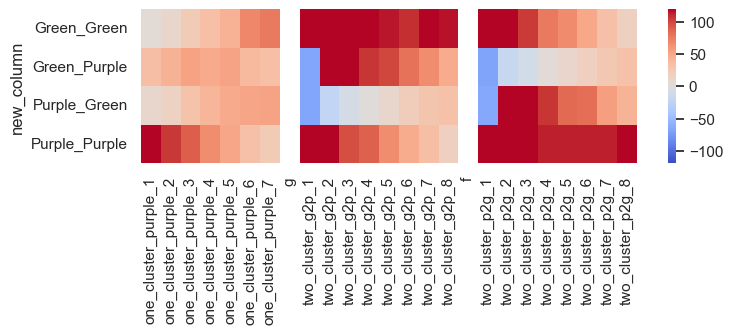

In [20]:
#save_df_transposed = save_df_transposed.reindex(desired_order)
gap_col_name = 'g'  # or something meaningful
gap_col_name2 = 'f'
cols = list(save_df_filtered.columns)
save_df_filtered.insert(7, gap_col_name, np.nan)
save_df_filtered.insert(16, gap_col_name2, np.nan)

plt.figure(figsize=(8,2))
save_df_filtered = save_df_filtered.apply(pd.to_numeric, errors='coerce')
sns.heatmap(save_df_filtered, cmap='coolwarm', vmax = 120, vmin = -120)


# Save the figure as SVG
plt.savefig(f"{path_to_csv}results_cozi_onecluster_heatmap.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [44]:
# SEA
save_df = adata.uns['sea_scimap']
# Convert 'phenotype' and 'neighbour_phenotype' columns to string types
save_df['phenotype'] = save_df['phenotype'].astype(str)
save_df['neighbour_phenotype'] = save_df['neighbour_phenotype'].astype(str)

# Combine 'phenotype' and 'neighbour_phenotype' into 'new_column'
save_df['new_column'] = save_df['phenotype'] + "_" + save_df['neighbour_phenotype']
save_df = save_df.drop(columns=['phenotype', 'neighbour_phenotype'])
save_df = save_df.set_index('new_column')

# Transpose the dataframe
save_df_transposed = save_df.transpose()
save_df_transposed.columns = save_df_transposed.columns.str.replace(r"\.0",
                                                                    "",
                                                                    regex=True)
save_df_transposed = save_df_transposed[~save_df_transposed.index.str.contains('pvalue')]
save_df_transposed = save_df_transposed[~save_df_transposed.index.str.contains('count')]
save_df_transposed = save_df_transposed[~save_df_transposed.index.str.contains('cond_cell')]
save_df_transposed.index = save_df_transposed.index.str.replace(r"zscore_", "", regex=True)

# View the transposed dataframe (optional)
save_df_transposed = save_df_transposed.sort_index().transpose()

# Since you set 'new_column' as index, you can filter like this:
save_df_filtered = save_df_transposed.loc[save_df.index.isin(interactions_to_keep)]
save_df_filtered


,one_cluster_purple_1,one_cluster_purple_2,one_cluster_purple_3,one_cluster_purple_4,one_cluster_purple_5,one_cluster_purple_6,one_cluster_purple_7,two_cluster_g2p_1,two_cluster_g2p_2,two_cluster_g2p_3,...,two_cluster_g2p_7,two_cluster_g2p_8,two_cluster_p2g_1,two_cluster_p2g_2,two_cluster_p2g_3,two_cluster_p2g_4,two_cluster_p2g_5,two_cluster_p2g_6,two_cluster_p2g_7,two_cluster_p2g_8
new_column,,,,,,,,,,,,,,,,,,,,,
Green_Green,19.76,25.41,43.78,58.81,70.05,88.25,105.91,160.82,140.13,128.51,...,133.75,131.23,159.91,139.51,115.64,96.37,90.77,75.46,55.44,37.36
Green_Purple,39.38,51.66,63.36,70.80,83.68,64.78,64.46,-51.54,-30.07,-9.87,...,29.91,35.79,-52.76,-29.75,-14.95,4.46,12.59,22.10,29.32,34.27
Purple_Green,39.65,52.10,64.47,68.72,69.80,73.52,67.32,-47.79,-29.15,-9.76,...,30.08,33.20,-48.00,-27.03,-15.22,4.00,12.67,23.96,28.12,31.29
Purple_Purple,142.63,130.13,111.34,94.99,75.85,55.62,47.23,167.96,155.68,123.03,...,60.37,39.32,165.32,155.70,135.03,120.29,124.51,121.96,121.87,127.80


In [45]:
# save save_df_filtered as xlsx
save_df_filtered.to_excel("./../../../../../data/Source_data/Source_4b.xlsx")

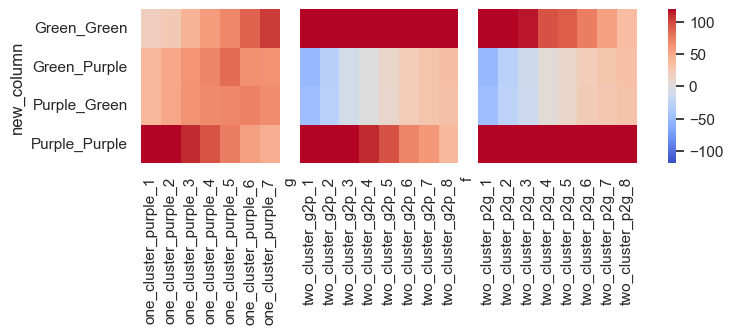

In [24]:
#save_df_transposed = save_df_transposed.reindex(desired_order)
gap_col_name = 'g'  # or something meaningful
gap_col_name2 = 'f'
cols = list(save_df_filtered.columns)
save_df_filtered.insert(7, gap_col_name, np.nan)
save_df_filtered.insert(16, gap_col_name2, np.nan)

plt.figure(figsize=(8,2))
save_df_filtered = save_df_filtered.apply(pd.to_numeric, errors='coerce')
sns.heatmap(save_df_filtered, cmap='coolwarm', vmax = 120, vmin = -120)


# Save the figure as SVG
plt.savefig(f"{path_to_csv}results_sea_onecluster_heatmap.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [30]:
df = adata.uns['cozi_scimap'].copy()
df

,phenotype,neighbour_phenotype,zscore_two_cluster_g2p_5,pvalue_two_cluster_g2p_5,cond_cell_ratio_two_cluster_g2p_5,cond_cell_count_two_cluster_g2p_5,zscore_two_cluster_g2p_4,pvalue_two_cluster_g2p_4,cond_cell_ratio_two_cluster_g2p_4,cond_cell_count_two_cluster_g2p_4,...,cond_cell_count_two_cluster_p2g_2,zscore_two_cluster_p2g_3,pvalue_two_cluster_p2g_3,cond_cell_ratio_two_cluster_p2g_3,cond_cell_count_two_cluster_p2g_3,zscore_two_cluster_g2p_8,pvalue_two_cluster_g2p_8,cond_cell_ratio_two_cluster_g2p_8,cond_cell_count_two_cluster_g2p_8,new_column
0,Green,Green,115.68,0.00,0.98,1435,122.29,0.00,0.97,1347,...,1039,105.63,0.00,1.00,945,116.86,0.00,1.00,1677,Green_Green
1,Green,Others,-54.08,0.00,0.12,180,-50.18,0.00,0.12,171,...,122,-33.61,0.00,0.11,105,-63.99,0.00,0.12,210,Green_Others
2,Green,Purple,100.89,0.00,0.30,441,107.24,0.00,0.24,333,...,500,-9.51,0.00,0.66,629,48.68,0.00,0.39,656,Green_Purple
3,Others,Green,-18.06,0.00,0.07,209,-14.65,0.00,0.07,200,...,147,4.01,0.00,0.05,139,-30.88,0.00,0.08,245,Others_Green
4,Others,Others,160.67,0.00,1.00,2879,157.97,0.00,1.00,2835,...,2733,155.13,0.00,1.00,2775,166.09,0.00,1.00,2996,Others_Others
5,Others,Purple,3.96,0.00,0.04,106,6.37,0.00,0.04,116,...,150,-6.53,0.00,0.06,180,9.18,0.00,0.02,48,Others_Purple
6,Purple,Green,10.87,0.00,0.92,612,2.17,0.03,0.82,633,...,121,124.21,0.00,0.17,214,32.75,0.00,1.00,323,Purple_Green
7,Purple,Others,-29.06,0.00,0.11,72,-33.26,0.00,0.11,88,...,135,-42.67,0.00,0.12,153,-28.03,0.00,0.10,34,Purple_Others
8,Purple,Purple,67.40,0.00,1.00,660,89.50,0.00,1.00,773,...,1167,135.53,0.00,0.95,1215,19.00,0.00,0.86,278,Purple_Purple


In [38]:
### DOTPLOT HEATMAP COZI

# Start with this: the wide format `save_df` as you showed earlier
df = adata.uns['cozi_scimap'].copy()
df['phenotype'] = df['phenotype'].astype(str)
df['neighbour_phenotype'] = df['neighbour_phenotype'].astype(str)

# Create interaction label
df['interaction'] = df['phenotype'] + "_" + df['neighbour_phenotype']

# Melt the dataframe into long format
df_melted = df.melt(id_vars=['phenotype', 'neighbour_phenotype', 'interaction'], var_name='metric', value_name='value')

# Extract type of metric and condition
df_melted['metric_type'] = df_melted['metric'].str.extract(r'^(zscore|cond_cell_ratio)')
df_melted['condition'] = df_melted['metric'].str.replace(r'^(zscore|cond_cell_ratio)_', '', regex=True)

# Pivot so we get one row per (interaction, condition) with both zscore and cond_cells
df_pivot = df_melted.pivot_table(index=['interaction', 'condition'], 
                                 columns='metric_type', 
                                 values='value').reset_index()

df_pivot['zscore'] = pd.to_numeric(df_pivot['zscore'], errors='coerce').astype(float)
df_pivot['cond_cell_ratio'] = pd.to_numeric(df_pivot['cond_cell_ratio'], errors='coerce').astype(float)




In [39]:
interactions_to_keep = ['Green_Green', 'Green_Purple', 'Purple_Green', 'Purple_Purple']

# Since you set 'new_column' as index, you can filter like this:
save_df_filtered = df_pivot[df_pivot['interaction'].isin(interactions_to_keep)]
save_df_filtered

metric_type,interaction,condition,cond_cell_ratio,zscore
0,Green_Green,one_cluster_purple_1,0.59,5.48
1,Green_Green,one_cluster_purple_2,0.67,10.84
2,Green_Green,one_cluster_purple_3,0.86,23.45
3,Green_Green,one_cluster_purple_4,0.94,34.19
4,Green_Green,one_cluster_purple_5,0.98,44.66
...,...,...,...,...
202,Purple_Purple,two_cluster_p2g_4,0.97,113.78
203,Purple_Purple,two_cluster_p2g_5,0.98,114.41
204,Purple_Purple,two_cluster_p2g_6,0.99,114.34
205,Purple_Purple,two_cluster_p2g_7,0.99,113.23


In [40]:
# Make sure 'condition' is categorical with an explicit order
conditions = list(save_df_filtered['condition'].unique())

# Insert visual gap labels after index 6 and 15
conditions.insert(7, 'GAP_1')
conditions.insert(16, 'GAP_2')  # 17 because list is now longer by 1

# Set the new order
save_df_filtered['condition'] = pd.Categorical(save_df_filtered['condition'],
                                               categories=conditions,
                                               ordered=True)
save_df_filtered

/var/folders/79/cjwcycvd2_9dyfffbym60x200000gn/T/ipykernel_63513/1597646204.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



metric_type,interaction,condition,cond_cell_ratio,zscore
0,Green_Green,one_cluster_purple_1,0.59,5.48
1,Green_Green,one_cluster_purple_2,0.67,10.84
2,Green_Green,one_cluster_purple_3,0.86,23.45
3,Green_Green,one_cluster_purple_4,0.94,34.19
4,Green_Green,one_cluster_purple_5,0.98,44.66
...,...,...,...,...
202,Purple_Purple,two_cluster_p2g_4,0.97,113.78
203,Purple_Purple,two_cluster_p2g_5,0.98,114.41
204,Purple_Purple,two_cluster_p2g_6,0.99,114.34
205,Purple_Purple,two_cluster_p2g_7,0.99,113.23


In [41]:
# save save_df_filtered as xlsx file
save_df_filtered.to_excel("./../../../../../data/Source_data/Source_4e.xlsx")

/var/folders/79/cjwcycvd2_9dyfffbym60x200000gn/T/ipykernel_63513/1018985552.py:20: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



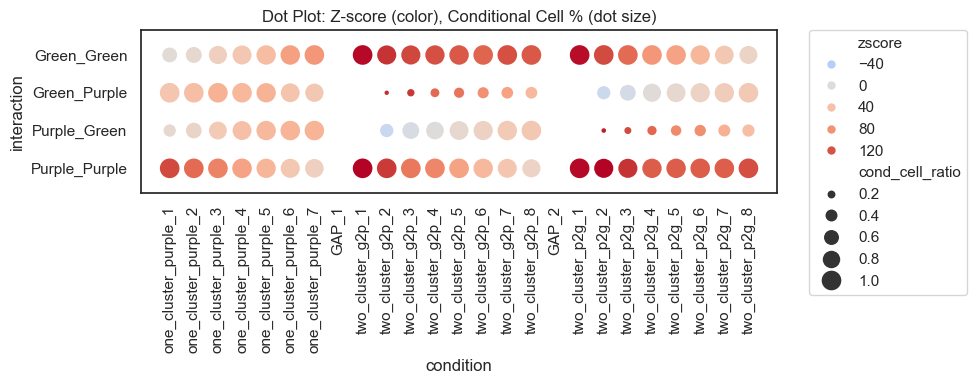

In [42]:


# Plot (unchanged code, but will now have gaps)
from matplotlib.colors import TwoSlopeNorm
plt.figure(figsize=(10, 4))
sns.set(style='white')

plot = sns.scatterplot(
    data=save_df_filtered,
    x='condition',
    y='interaction',
    size='cond_cell_ratio',
    hue='zscore',
    sizes=(10, 200),
    palette='coolwarm',
    edgecolor='gray',
    hue_norm=TwoSlopeNorm(vmin=-150, vcenter=0, vmax=150),
    linewidth=0
)

# Extend the x-axis to leave space for blank columns
plot.set_xticklabels(plot.get_xticklabels(), rotation=90)

# Expand y-axis limits to avoid clipping of top/bottom dots
bottom, top = plot.get_ylim()
plot.set_ylim(bottom + 0.5, top - 0.5)

#plt.grid(axis='y', linestyle='--', color='lightgray')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title('Dot Plot: Z-score (color), Conditional Cell % (dot size)')
plt.tight_layout()

plt.savefig(f"{path_to_csv}results_twocluster_cozi_finalsub.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()
plt.close()